# **REGRESIÓN LOGÍSTICA MULTINOMIAL — Titanic Dataset**

In [2]:
# Paso 1: Preparar los datos

import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset Titanic desde Seaborn
data = sns.load_dataset('titanic')

# Seleccionar columnas relevantes
data = data[['pclass', 'age', 'fare', 'sex']]

# Eliminar filas con valores nulos
data = data.dropna()

# Vista previa
print("Vista previa del dataset:")
display(data.head())
print(f"Registros después de limpieza: {data.shape[0]}")

Vista previa del dataset:


,pclass,age,fare,sex
0,3,22.0,7.2500,male
1,1,38.0,71.2833,female
2,3,26.0,7.9250,female
3,1,35.0,53.1000,female
4,3,35.0,8.0500,male


Registros después de limpieza: 714


In [3]:
# Paso 2: Codificación profesional

# Codificar variable categórica 'sex' → dummy variable (drop_first evita multicolinealidad)
data = pd.get_dummies(data, columns=['sex'], drop_first=True)

# Asegurar tipo entero (0 y 1)
data['sex_male'] = data['sex_male'].astype(int)

# Vista de datos codificados
print("Datos después de codificación:")
display(data.head())

Datos después de codificación:


,pclass,age,fare,sex_male
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1


In [4]:
# Paso 3: Definir variables predictoras (X) y objetivo (y)

# Variables predictoras o Independiente
X = data[['age', 'fare', 'sex_male']]

# Variable objetivo (multiclase) o Independiente con varios estatus o niveles
y = data['pclass']

print("Dimensiones de X e y:")
print("X:", X.shape, "y:", y.shape)

Dimensiones de X e y:
X: (714, 3) y: (714,)


In [9]:
data['pclass'].unique()

array([3, 1, 2])

In [6]:
# Paso 4: Dividir datos y entrenar modelo

# División entrenamiento/prueba con estratificación (mantiene proporciones de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Instanciar modelo de regresión logística multinomial
modelo = LogisticRegression(
    multi_class='multinomial',     # Clasificación multiclase
    solver='lbfgs',                # Optimizador robusto
    max_iter=200,                  # Iteraciones suficientes
    random_state=42
)

# Entrenar modelo
modelo.fit(X_train, y_train)

from IPython.display import Markdown
display(Markdown("<span style='color:darkblue; font-size:20px; font-weight:bold;'>Modelo entrenado correctamente.</span>"))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


<span style='color:darkblue; font-size:20px; font-weight:bold;'>Modelo entrenado correctamente.</span>

In [7]:
# Paso 5: Evaluación del modelo

# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

# Reporte de clasificación
reporte = classification_report(y_test, y_pred, digits=2)
print("\nReporte de clasificación:\n")
print(reporte)

Matriz de confusión:
[[ 51   3   2]
 [  6  15  31]
 [  2   4 101]]

Reporte de clasificación:

              precision    recall  f1-score   support

           1       0.86      0.91      0.89        56
           2       0.68      0.29      0.41        52
           3       0.75      0.94      0.84       107

    accuracy                           0.78       215
   macro avg       0.77      0.71      0.71       215
weighted avg       0.77      0.78      0.75       215



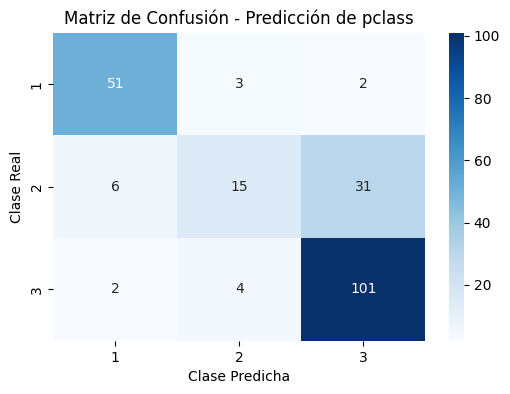

In [8]:
# Paso 6: Visualización de la matriz de confusión

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.title('Matriz de Confusión - Predicción de pclass')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.show()

# **1 ¿Qué representa la matriz de confusión?**

Cada número indica cuántas observaciones fueron clasificadas correctamente o incorrectamente por el modelo.

* ## Las filas representan las clases reales (verdaderas).

* ## Las columnas representan las clases predichas por el modelo.

# **2. Interpretación por clase**

**Clase 1 (Primera clase)**

51 pasajeros fueron correctamente clasificados como de primera clase → (diagonal principal).

3 fueron confundidos como de segunda clase.

2 fueron confundidos como de tercera clase.

**Conclusión:** El modelo tiene muy buena precisión y recall para la primera clase.
Predice correctamente a casi todos los pasajeros de primera clase.

**Clase 2 (Segunda clase)**

15 fueron clasificados correctamente.

6 fueron confundidos como de primera clase.

31 fueron confundidos como de tercera clase.

**Conclusión:** Aquí el modelo tiene problemas.
Predice muy pocos pasajeros de segunda clase correctamente (recall bajo).
Tiende a confundirlos con la tercera clase, lo que sugiere solapamiento de características (edad, tarifa o sexo similares).

**Clase 3 (Tercera clase)**

101 pasajeros fueron clasificados correctamente.

2 fueron confundidos como de primera clase.

4 fueron confundidos como de segunda clase.

**Conclusión:** Excelente desempeño.

El modelo identifica muy bien a los pasajeros de tercera clase, con apenas unos pocos errores.

# **Conclusión General**

Clase 1: Excelente precisión y recall (modelo identifica bien a los pasajeros de primera clase).

Clase 2: Recall bajo; el modelo confunde varios pasajeros de segunda con tercera clase.

Clase 3: Buen desempeño general, aunque con algunos falsos positivos.

Accuracy global ≈ 78 %, pero el macro avg (~0.71) evidencia que la clase intermedia (2ª) limita el rendimiento global.

En proyectos reales podrías mejorar el desempeño equilibrando clases (SMOTE, class_weight='balanced') o añadiendo nuevas variables predictoras (por ejemplo, número de familiares, puerto de embarque, cabina).#

# **¿Qué hacemos para mejorar el modelo?**

El modelo predice bien la primera y tercera clase, pero se confunde con la segunda. Esto puede deberse a que hay menos ejemplos de esa clase o a que sus características se parecen a las de la tercera.

Para mejorar, se puede equilibrar las clases usando class_weight='balanced' o aplicar SMOTE para generar más ejemplos de la clase 2. Así el modelo aprenderá de forma más justa entre todas las categorías.

También conviene agregar más variables, como sibsp, parch o embarked, que aportan información extra sobre el pasajero y ayudan a diferenciar mejor las clases.

Además, es útil normalizar los valores numéricos como edad y tarifa, para que el modelo no dé más peso a una variable solo por su escala.

Como las clases tienen un orden (1°, 2°, 3°), se puede usar una regresión logística ordinal, que respeta esa jerarquía y da resultados más coherentes.

Por último, se recomienda ajustar los parámetros del modelo con GridSearchCV para mejorar su rendimiento general. Con estas mejoras, el modelo será más equilibrado y preciso.
